# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 44     |  |
| :-------------|:-------------|
| Frank de Kogel|  6582737|
| Ole Doekes| 6489028|
| Daniel Shou| 6501540 |

| Planning Groep: 44     |Tijdstip / Tijdspanne  |
|mijlpaal 1: github |10:45|
|Mijlpaal 2: weerstandjes checken |11:30| 
|Mijlpaal 3: nadenken over welke 3 weerstanden gekozen worden en 3 applicaties bedenken|12:10|
| Mijlpaal 4: Criteria opgesteld | 12:30 |
| Pauze 1| 12:30-13:30 |
| Mijlpaal 5: Eerste kalibratie meting gedaan| 14:45 |
|mijlpaal 6: eind conclusies trekken|15:15|
|mijlpaal 7: evaluatie en feedback|16:00|
|eindmijlpaal 8: opruimen en afsluiten|  |
| Pauze 2| 16:00-16:30 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![image](./20260218_113526.jpg)

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Force Sensor | Breektest | Sensor heeft meetfrequentie van minimaal 10 Hertz hebben|
|Force Sensor | Breektest | Sensor moet nauwkeurig zijn op 50 gram|
|Force Sensor | Breektest | Sensor moet accuraat zijn tussen 50 gram en 5 kilo|
| Hall effect sensor| Open raam detecteren | Geeft binaire output|
| Hall effect sensor| Open raam detecteren| Meet afstand raam van 0 to 10 cm met resolutie van 3 mm|
| Hall effect sensor | Open raam detecteren | Sensor check minimaal 1 keer per minuut |
|Thermistor | Ventilator regeling | Reageert <1 minuut op veranderingen in temperatuur|
|Thermistor | Ventilator regeling | is 1 graad nauwkeurig tussen 10 en 40 graden|
|Thermistor | Ventilator regeling | Plaatst temperatuur in drie bins (10-20 graden, 20-30 graden, 30-40 graden) om ventilator te sturen|

Groep 44 heeft gekozen voor sensor Force Sensor (breektest). 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](20260218_163835.jpg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
2. Over welk bereik ga je deze variabelen veranderen?
3. Wat ga je allemaal meten?
4. Hoeveel metingen ga je doen?
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?

1. We gaan verschillende bekende massa's op onze krachtsensor zetten.
2. Deze massa's zijn we van plan te varieren tussen 20 gram en vijf kilo, om een diverse dataset te krijgen.
3. We meten met de arduino de spanning die de weerstandsdeler geeft.
4. We zijn van plan 12 metingen te doen.
5. Als blijkt dat er uit een gefitte curve door onze meetpunten een duidelijk en betrouwbaar verband tussen de waarde die Arduino waarneemt en het gewicht bestaat, dan is de sensor geschikt. De sensor wordt uitgerust met een druppel lijm, zodat de tandenstoker accuraat gepositioneerd kan worden. Tevens wordt de opstelling zo bereid dat de tandenstoker aan de linkerzijde op de druksensor ligt en aan de rechterzijde gefixeerd is. Hierna wordt er door middel van een pen kracht uitgeoefend op het midden van de tandenstoker. We verwachten in onze gekalibreerde metingen een piek te zien, waarbij de kracht maximaal is, waarna de kracht scherp afneemt, omdat de tandenstoker breekt.


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![image](20260218_153919.jpg)
 Hier is te zien hoe een tandenstoker wordt gebroken terwijl de sensor de kracht meet.

## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit


weights = np.array([0, 114.8, 196.4, 287.3, 333.6, 396.3, 529.1, 1330.6, 1860, 2307, 3281, 4135, 4632]) # Dit zijn massas in grammen
measurements = np.array([0, 561, 688, 805, 825, 860, 870, 920, 933, 943, 947, 951, 955]) # Door de arduino gemeten waarde, 0-1023


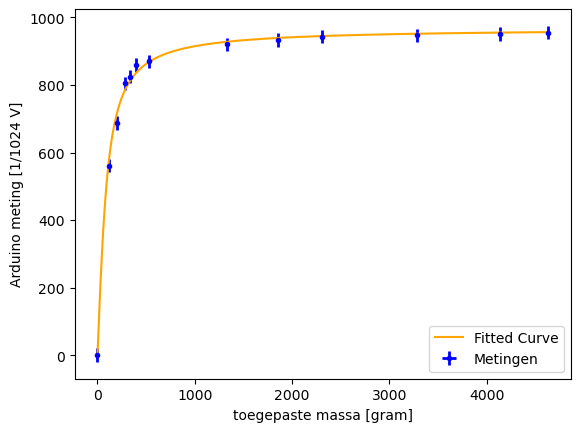

[ 6.16354990e+02  1.15470023e-02 -5.21558993e-03]


In [2]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
def fitFunc(weight, a, b, c):
    return a * np.arctan(b*weight+c)

val, cov = curve_fit(fitFunc, weights, measurements, p0=[1000, 1, -50])

u_mass = 1 # Onzekerheid van 1 gram
u_meas = 20 # metingen van de arduino schommelden met amplitude 20.

weightTest = np.linspace(weights[0], weights[-1], 1000)
measTest = fitFunc(weightTest, val[0], val[1], val[2])
plt.errorbar(weights, measurements, yerr=u_meas, xerr=u_mass, marker='.', color='blue', linewidth=0, elinewidth=2, label='Metingen')
plt.plot(weightTest, measTest, label="Fitted Curve", color='orange')
plt.xlabel("toegepaste massa [gram]")
plt.ylabel("Arduino meting [1/1024 V]")
plt.legend()
plt.show()
print(val)

# Het valt zeker op dat de curve hard afvlakt, hierdoor hebben we er weinig aan bij gewichten > 1kg



In [3]:
# Nu meten we bij welk gewicht de tandenstoker breekt

breakWeights = np.array([176.08, 211.31, 231.19, 170.89, 224.36, 159.02, 169.42, 184.24, 160.76, 149.71, 118.48, 164.26, 154.38, 165.14, 129.2, 150.28, 129.21, 155.16, 133.4, 104.91, 148.75, 127.4, 178.28, 139.58, 165.94])

print("Gemiddelde breukwaarde:", np.mean(breakWeights), "+/-", np.std(breakWeights), "gram")

Gemiddelde breukwaarde: 160.054 +/- 30.024391817320794 gram


## *Opdracht 7*: Iteratie nodig?

De curve-fit past goed, dus wij gaan niet verder de krachtsensor itereren. Echter bleek dat de aanname dat een gewicht van enkele kilos gemeten wordt bij het breken van de tandenstokers niet correct, en bleek dat het gemiddelde gewicht tijdens het breken ongeveer 160 gram is. De massa-meetwaarde curve vlakt erg af bij hoge massa's, wat het accuraat meten van hoge massa's niet toestaat.

## *Opdracht 8*: Conclusie, leerdoel

Door middel van verschillende vergelijkingstesten bleek dat de sensor niet binnen 50 gram accuraat. Hierdoor bleken de waarnemingen van het breukgewicht niet betrouwbaar. Hoewel het erg goed lukte om een curvefit te produceren, bleken er onvoldoende meetpunten gemaakt te zijn bij de gewichten onder 1 kilo. Ook bleek uit het gedrag van de sensor dat de sensor bij gewichten boven de 1 kilo er, volgens de arctangens functie, weinig verandering in de spanning is bij een grote verandering in de kracht: hierdoor is het zeer lastig een accurate meting uit te voeren bij een hoge kracht, en er waren te weinig kalibratiepunten voor een accuraat gedrag onder 1 kilo. Al met al bleek de sensor niet geschikt voor het accuraat berekenen van de breukkracht van een tandenstoker omdat deze niet goed meten kan bij hoge gewichten en niet accuraat is bij lage gewichten. 

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![image](20260218_153919.jpg)
 Hier is te zien hoe een tandenstoker wordt gebroken terwijl de sensor de kracht meet.

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Force Sensor | Breektest | Sensor heeft meetfrequentie van minimaal 10 Hertz hebben|
|Force Sensor | Breektest | Sensor moet nauwkeurig zijn op 50 gram|
|Force Sensor | Breektest | Sensor moet accuraat zijn tussen 50 gram en 5 kilo|
| Hall effect sensor| Open raam detecteren | Geeft binaire output|
| Hall effect sensor| Open raam detecteren| Meet afstand raam van 0 to 10 cm met resolutie van 3 mm|
| Hall effect sensor | Open raam detecteren | Sensor check minimaal 1 keer per minuut |
|Thermistor | Ventilator regeling | Reageert <1 minuut op veranderingen in temperatuur|
|Thermistor | Ventilator regeling | is 1 graad nauwkeurig tussen 10 en 40 graden|
|Thermistor | Ventilator regeling | Plaatst temperatuur in drie bins (10-20 graden, 20-30 graden, 30-40 graden) om ventilator te sturen|

Groep 44 heeft gekozen voor sensor Force Sensor (breektest). 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

## *Opdracht 6*: Meten en fitten, Leerdoel

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit


weights = np.array([0, 114.8, 196.4, 287.3, 333.6, 396.3, 529.1, 1330.6, 1860, 2307, 3281, 4135, 4632])
measurements = np.array([0, 561, 688, 805, 825, 860, 870, 920, 933, 943, 947, 951, 955])


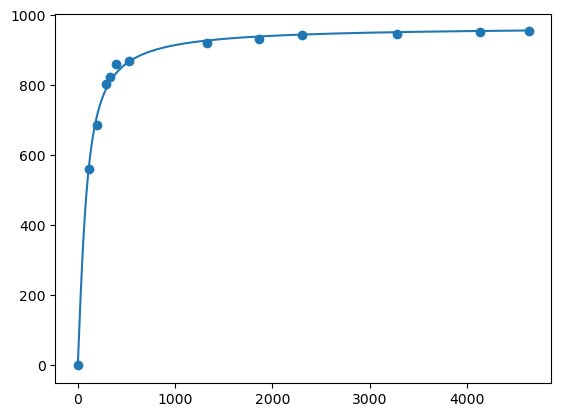

[ 6.16354990e+02  1.15470023e-02 -5.21558993e-03]


In [5]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
def fitFunc(weight, a, b, c):
    return a * np.arctan(b*weight+c)

val, cov = curve_fit(fitFunc, weights, measurements, p0=[1000, 1, -50])

weightTest = np.linspace(weights[0], weights[-1], 1000)
measTest = fitFunc(weightTest, val[0], val[1], val[2])
plt.scatter(weights, measurements)
plt.plot(weightTest, measTest)
plt.show()
print(val)


In [6]:
# Nu meten we bij welk gewicht de tandenstoker breekt

breakWeights = np.array([176.08, 211.31, 231.19, 170.89, 224.36, 159.02, 169.42, 184.24, 160.76, 149.71, 118.48, 164.26, 154.38, 165.14, 129.2, 150.28, 129.21, 155.16, 133.4, 104.91, 148.75, 127.4, 178.28, 139.58, 165.94])

print("Gemiddelde breukwaarde:", np.mean(breakWeights), "+/-", np.std(breakWeights), "gram")

Gemiddelde breukwaarde: 160.054 +/- 30.024391817320794 gram


## *Opdracht 8*: Conclusie, leerdoel

Door middel van verschillende vergelijkingstesten bleek dat de sensor niet binnen 50 gram accuraat. Hierdoor bleken de waarnemingen van het breukgewicht niet betrouwbaar. Hoewel het erg goed lukte om een curvefit te produceren, bleken er onvoldoende meetpunten gemaakt te zijn bij de gewichten onder 1 kilo. Ook bleek uit het gedrag van de sensor dat de sensor bij gewichten boven de 1 kilo er, volgens de arctangens functie, weinig verandering in de spanning is bij een grote verandering in de kracht: hierdoor is het zeer lastig een accurate meting uit te voeren bij een hoge kracht, en er waren te weinig kalibratiepunten voor een accuraat gedrag onder 1 kilo. Al met al bleek de sensor niet geschikt voor het accuraat berekenen van de breukkracht van een tandenstoker omdat deze niet goed meten kan bij hoge gewichten en niet accuraat is bij lage gewichten. 

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![image](20260218_153919.jpg)
 Hier is te zien hoe een tandenstoker wordt gebroken terwijl de sensor de kracht meet.